# Sửa cân bằng `λ_feat` cho FitNets — train lại 6 epoch — gộp so sánh 4 phương pháp

**Notebook này gồm 2 phần:**

- **Phần A (mục 1-9):** sửa `FitNetsMultiLayer` (chuẩn hoá L2 đặc trưng trước MSE, thay vì MSE thô
  như bản gốc) và train lại **CHỈ FitNets** đủ 6 epoch — không đụng đến AT/MGD/SPKD.
- **Phần B (mục 10-14):** tải lại 3 checkpoint AT/MGD/SPKD đã có trên HF, gộp
  cùng FitNets-mới vừa train, đưa ra **1 bảng + biểu đồ so sánh đầy đủ 4 phương pháp** (metric,
  latency, và mẫu caption định tính) trong cùng notebook.

In [5]:
!pip install -q "transformers>=4.41" accelerate huggingface_hub
!pip install -q pycocoevalcap rouge_score evaluate nltk


In [6]:
import gc
import json
import logging
import os
import random
import time
import zipfile
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import HfApi, create_repo, hf_hub_download
from PIL import Image
from torch.optim import AdamW
from transformers import BlipForConditionalGeneration, BlipProcessor, get_linear_schedule_with_warmup

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("fitnets_fix_and_compare")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"CUDA available: {torch.cuda.is_available()} | Device: {DEVICE}")


20:53:12 | INFO    | CUDA available: True | Device: cuda


## 1. Cấu hình

In [7]:
@dataclass
class DataConfig:
    hf_repo_id: str = "qa994/fashion200k_10k"
    train_zip: str = "fashion200k_train.zip"
    val_zip: str = "fashion200k_val.zip"
    test_zip: str = "fashion200k_test.zip"
    cache_dir: str = "/kaggle/working/hf_cache_fitnets_fix"


@dataclass
class ArchConfig:
    teacher_name: str = "Salesforce/blip-image-captioning-large"
    student_name: str = "Salesforce/blip-image-captioning-base"
    keep_decoder_layers: Tuple[int, ...] = (0, 3, 6, 9)
    hint_fractions: Tuple[float, ...] = (0.25, 0.5, 0.75, 1.0)


@dataclass
class GenConfig:
    num_beams: int = 1
    max_new_tokens: int = 32
    min_new_tokens: int = 6
    no_repeat_ngram_size: int = 3
    repetition_penalty: float = 1.3
    use_cache: bool = True

    def as_kwargs(self) -> dict:
        return {
            "num_beams": self.num_beams, "max_new_tokens": self.max_new_tokens,
            "min_new_tokens": self.min_new_tokens, "no_repeat_ngram_size": self.no_repeat_ngram_size,
            "repetition_penalty": self.repetition_penalty, "use_cache": self.use_cache,
        }


@dataclass
class TeacherCheckpointConfig:
    """Teacher DA fine-tune tu truoc — chi tai ve dung, KHONG fine-tune lai."""
    repo_id: str = "qa994/blip-teacher-fashion200k"
    filename: str = "teacher_checkpoint.pth"
    repo_type: str = "model"


@dataclass
class FitNetsFixConfig:
    """Cau hinh sua can bang loss cho FitNets — dua tren ket qua notebook probe truoc do."""
    normalize_feature: bool = True  # Chinh sua chinh: L2-normalize dac trung TRUOC khi tinh MSE
    lambda_feature_override: Optional[float] = None  # dat gia tri < 1.0 neu sau khi chuan hoa van con lech


@dataclass
class TrainConfig:
    num_epochs: int = 6
    batch_size: int = 4
    grad_accum_steps: int = 1
    lr: float = 1e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_grad_norm: float = 1.0
    temperature: float = 4.0
    lambda_response: float = 1.0
    lambda_feature: float = 1.0
    use_amp: bool = True
    max_len: int = 40


@dataclass
class RunConfig:
    output_root: str = "/kaggle/working/fitnets_fix_outputs"
    eval_batch_size: int = 8
    log_every_n_steps: int = 100
    calibration_check_batches: int = 20  # kiem tra nhanh ti le loss TRUOC khi cam ket train 6 epoch
    bright_colors: Tuple[str, ...] = ("#FF3366", "#FFC300", "#00E5FF", "#39FF14", "#B14EFF")


data_cfg = DataConfig()
arch_cfg = ArchConfig()
gen_cfg = GenConfig()
teacher_ckpt_cfg = TeacherCheckpointConfig()
fitnets_fix_cfg = FitNetsFixConfig()
train_cfg = TrainConfig()
run_cfg = RunConfig()
os.makedirs(run_cfg.output_root, exist_ok=True)
os.makedirs(data_cfg.cache_dir, exist_ok=True)
logger.info(f"FitNetsFixConfig: normalize_feature={fitnets_fix_cfg.normalize_feature}, lambda_override={fitnets_fix_cfg.lambda_feature_override}")


20:53:12 | INFO    | FitNetsFixConfig: normalize_feature=True, lambda_override=None


## 2. Tải dữ liệu (train + val + test — cần cả 3 vì lần này train thật đủ 6 epoch)

In [8]:
def load_split_from_hf(repo_id: str, filename: str, split_name: str, cache_dir: str) -> List[dict]:
    """Tai 1 file zip split tu HF Hub, giai nen, doc metadata.json."""
    try:
        zip_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset", cache_dir=cache_dir)
    except (OSError, ValueError) as e:
        raise RuntimeError(f"Khong tai duoc {filename} tu {repo_id}: {e}") from e

    target_dir = os.path.join(cache_dir, f"extracted_{split_name}")
    if not os.path.exists(target_dir):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(target_dir)
        except zipfile.BadZipFile as e:
            raise RuntimeError(f"File zip loi: {filename}: {e}") from e

    meta_path = os.path.join(target_dir, "metadata.json")
    with open(meta_path, encoding="utf-8") as f:
        metadata = json.load(f)
    for item in metadata:
        item["image_path"] = os.path.join(target_dir, item["image_file"])
    logger.info(f"[{split_name}] Da tai {len(metadata)} mau tu {filename}")
    return metadata


fashion_train = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.train_zip, "train", data_cfg.cache_dir)
fashion_val = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.val_zip, "val", data_cfg.cache_dir)
fashion_test = load_split_from_hf(data_cfg.hf_repo_id, data_cfg.test_zip, "test", data_cfg.cache_dir)
logger.info(f"Train: {len(fashion_train)} | Val: {len(fashion_val)} | Test: {len(fashion_test)}")

SHARED_PROCESSOR = BlipProcessor.from_pretrained(arch_cfg.student_name)
PAD_ID = SHARED_PROCESSOR.tokenizer.pad_token_id

sample_captions = [item["caption"] for item in fashion_train]
token_lengths = [len(SHARED_PROCESSOR.tokenizer.encode(c)) for c in sample_captions]
p95 = np.percentile(token_lengths, 95)
train_cfg.max_len = int(np.clip(np.ceil(p95 / 8) * 8, 24, 48))
logger.info(f"train_cfg.max_len = {train_cfg.max_len}")


20:53:12 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/fashion200k_10k/resolve/main/fashion200k_train.zip "HTTP/1.1 302 Found"
20:53:12 | INFO    | [train] Da tai 6999 mau tu fashion200k_train.zip
20:53:12 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/fashion200k_10k/resolve/main/fashion200k_val.zip "HTTP/1.1 302 Found"
20:53:12 | INFO    | [val] Da tai 1001 mau tu fashion200k_val.zip
20:53:12 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/fashion200k_10k/resolve/main/fashion200k_test.zip "HTTP/1.1 302 Found"
20:53:12 | INFO    | [test] Da tai 2003 mau tu fashion200k_test.zip
20:53:12 | INFO    | Train: 6999 | Val: 1001 | Test: 2003
20:53:12 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
20:53:12 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-capti

## 3. Metrics (giống hệt các notebook trước — để số liệu so sánh được)

In [9]:
import evaluate
from pycocoevalcap.cider.cider import Cider
import nltk

for pkg in ["wordnet", "punkt", "omw-1.4", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except (OSError, ValueError) as e:
        logger.warning(f"Khong tai duoc goi nltk '{pkg}': {e}")

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
cider_scorer = Cider()


def compute_all_metrics(predictions: List[str], references: List[str]) -> Dict[str, float]:
    """Tinh BLEU-4, BLEU-1, ROUGE-1/2/L, METEOR, CIDEr."""
    predictions = [p if p.strip() else "khong co mo ta" for p in predictions]
    bleu_res = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
    rouge_res = rouge_metric.compute(predictions=predictions, references=references)
    meteor_res = meteor_metric.compute(predictions=predictions, references=references)
    cider_refs = {i: [r] for i, r in enumerate(references)}
    cider_preds = {i: [p] for i, p in enumerate(predictions)}
    cider_score, _ = cider_scorer.compute_score(cider_refs, cider_preds)
    return {
        "BLEU-4": bleu_res["bleu"], "BLEU-1": bleu_res["precisions"][0],
        "ROUGE-1": rouge_res["rouge1"], "ROUGE-2": rouge_res["rouge2"], "ROUGE-L": rouge_res["rougeL"],
        "METEOR": meteor_res["meteor"], "CIDEr": cider_score,
    }


20:53:15 | INFO    | TensorFlow version 2.20.0 available.
20:53:15 | INFO    | JAX version 0.7.2 available.


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Prune decoder (+ reindex layer_idx) và hook feature nhiều tầng

In [10]:
def prune_decoder_layers(model: BlipForConditionalGeneration, keep_layer_indices: Tuple[int, ...]) -> BlipForConditionalGeneration:
    """Giu lai mot tap con cac tang decoder da pretrain."""
    decoder_layers = model.text_decoder.bert.encoder.layer
    n_original = len(decoder_layers)
    for idx in keep_layer_indices:
        if idx >= n_original:
            raise ValueError(f"keep_layer_indices co {idx} nhung decoder goc chi co {n_original} tang")
    pruned = nn.ModuleList([decoder_layers[i] for i in keep_layer_indices])
    model.text_decoder.bert.encoder.layer = pruned
    if hasattr(model.config, "text_config"):
        model.config.text_config.num_hidden_layers = len(keep_layer_indices)
    return model


def reindex_pruned_decoder_layers(model: BlipForConditionalGeneration) -> BlipForConditionalGeneration:
    """Gan lai layer_idx theo vi tri MOI sau khi prune — tranh IndexError khi generate()
    voi KV-cache tren cac ban Transformers moi (xem giai thich chi tiet o notebook probe truoc).
    """
    for new_idx, layer in enumerate(model.text_decoder.bert.encoder.layer):
        for _, module in layer.named_modules():
            if hasattr(module, "layer_idx"):
                module.layer_idx = new_idx
    return model


def compute_matched_layer_indices(n_layers: int, fractions: Tuple[float, ...]) -> List[int]:
    return sorted({min(n_layers - 1, max(0, round(f * n_layers) - 1)) for f in fractions})


class VisionFeatureHooks:
    """Bat feature map tai nhieu tang trung gian cua vision encoder, trong CUNG 1 lan forward."""

    def __init__(self, blip_model: BlipForConditionalGeneration, hint_layer_indices: List[int]):
        self.hint_layer_indices = sorted(hint_layer_indices)
        self.hidden_states: Dict[int, torch.Tensor] = {}
        self._handles = []
        encoder_layers = blip_model.vision_model.encoder.layers
        for idx in self.hint_layer_indices:
            handle = encoder_layers[idx].register_forward_hook(self._make_hook(idx))
            self._handles.append(handle)

    def _make_hook(self, idx: int):
        def hook(module, inputs, output):
            out = output[0] if isinstance(output, tuple) else output
            self.hidden_states[idx] = out
        return hook

    def get_hints(self) -> List[torch.Tensor]:
        return [self.hidden_states[i] for i in self.hint_layer_indices]

    def remove(self) -> None:
        for h in self._handles:
            h.remove()
        self._handles = []


def align_patch_tokens(student_tokens: torch.Tensor, target_num_tokens: int) -> torch.Tensor:
    """Can chinh so patch token cua Student cho khop Teacher bang noi suy song tuyen."""
    B, N, C = student_tokens.shape
    if N == target_num_tokens:
        return student_tokens
    cls_tok, patch_tok = student_tokens[:, :1, :], student_tokens[:, 1:, :]
    n_patch = patch_tok.shape[1]
    side = int(round(n_patch ** 0.5))
    if side * side != n_patch:
        logger.warning("So patch khong tao thanh luoi vuong hoan hao -> bo qua can chinh khong gian.")
        return student_tokens
    target_patch = target_num_tokens - 1
    target_side = int(round(target_patch ** 0.5))
    grid = patch_tok.permute(0, 2, 1).reshape(B, C, side, side)
    grid_resized = F.interpolate(grid, size=(target_side, target_side), mode="bilinear", align_corners=False)
    patch_resized = grid_resized.reshape(B, C, target_side * target_side).permute(0, 2, 1)
    return torch.cat([cls_tok, patch_resized], dim=1)


def make_labels(input_ids: torch.Tensor, pad_id: int) -> torch.Tensor:
    labels = input_ids.clone()
    labels[labels == pad_id] = -100
    labels[:, 0] = -100
    return labels


def free_gpu(*objs) -> None:
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 5. FitNets ĐÃ SỬA — chuẩn hoá L2 đặc trưng trước khi tính MSE

**Thay đổi duy nhất so với bản gốc:** thêm `F.normalize(..., p=2, dim=-1)` lên cả `projected`
(đặc trưng Student sau regressor) và `t_feat` (đặc trưng Teacher) trước khi tính MSE — vẫn ép khớp
đặc trưng từng token (đúng tinh thần FitNets), chỉ loại bỏ phần biên độ tuyệt đối gây áp đảo. Giữ
nguyên `compute_word_kd_loss` (Word-KD) không đổi.

In [11]:
def compute_word_kd_loss(student_logits: torch.Tensor, teacher_logits: torch.Tensor, pad_mask: torch.Tensor, temperature: float) -> torch.Tensor:
    """KL-divergence giua phan phoi token cua Student va Teacher (Hinton et al., 2015). KHONG DOI."""
    student_log_probs = F.log_softmax(student_logits.float() / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits.float() / temperature, dim=-1)
    kd_per_token = F.kl_div(student_log_probs, teacher_probs, reduction="none").sum(dim=-1)
    kd_per_token = kd_per_token * pad_mask
    return (kd_per_token.sum() / pad_mask.sum().clamp(min=1)) * (temperature ** 2)


class FitNetsMultiLayerFixed(nn.Module):
    """FitNets da tang, DA SUA: chuan hoa L2 tung vector dac trung (theo chieu hidden) TRUOC KHI
    tinh MSE — thay vi MSE THO tren gia tri dac trung nhu ban goc. Ket qua probe cho thay ban goc
    co loss_feature lon hon (loss_gt+loss_resp) toi ~121 lan, day la nguyen nhan chinh khien FitNets
    cho CIDEr rat thap (0.066) du van la implement dung cong thuc FitNets goc (Romero et al., 2015).
    """

    def __init__(self, student_hidden: int, teacher_hidden: int, n_hint_layers: int, normalize: bool = True):
        super().__init__()
        self.regressors = nn.ModuleList([nn.Linear(student_hidden, teacher_hidden) for _ in range(n_hint_layers)])
        self.normalize = normalize

    def forward(self, student_feats: List[torch.Tensor], teacher_feats: List[torch.Tensor]) -> torch.Tensor:
        losses = []
        for reg, s_feat, t_feat in zip(self.regressors, student_feats, teacher_feats):
            s_aligned = align_patch_tokens(s_feat, t_feat.shape[1])
            projected = reg(s_aligned.float())
            target = t_feat.float()
            if self.normalize:
                projected = F.normalize(projected, p=2, dim=-1)
                target = F.normalize(target, p=2, dim=-1)
            losses.append(F.mse_loss(projected, target))
        return torch.stack(losses).mean()


## 6. Teacher (tải checkpoint fine-tuned có sẵn — KHÔNG fine-tune lại)

In [12]:
def build_teacher(arch_cfg: ArchConfig) -> BlipForConditionalGeneration:
    teacher = BlipForConditionalGeneration.from_pretrained(arch_cfg.teacher_name, torch_dtype=torch.float16).to(DEVICE).eval()
    for p in teacher.parameters():
        p.requires_grad = False
    return teacher


try:
    teacher_ckpt_path = hf_hub_download(
        repo_id=teacher_ckpt_cfg.repo_id, filename=teacher_ckpt_cfg.filename,
        repo_type=teacher_ckpt_cfg.repo_type, cache_dir=data_cfg.cache_dir,
    )
except (OSError, ValueError) as e:
    raise RuntimeError(f"Khong tai duoc checkpoint Teacher: {e}") from e

teacher_model = build_teacher(arch_cfg)
try:
    teacher_model.load_state_dict(torch.load(teacher_ckpt_path, map_location=DEVICE), strict=True)
except RuntimeError as e:
    raise RuntimeError(f"load_state_dict Teacher that bai: {e}") from e
teacher_model = teacher_model.half().eval()
logger.info(f"Da load Teacher (fine-tuned) tu {teacher_ckpt_path}")

TEACHER_N_VISION_LAYERS = len(teacher_model.vision_model.encoder.layers)
TEACHER_HINT_LAYER_IDX = compute_matched_layer_indices(TEACHER_N_VISION_LAYERS, arch_cfg.hint_fractions)
TEACHER_VISION_HIDDEN = teacher_model.config.vision_config.hidden_size
teacher_hooks = VisionFeatureHooks(teacher_model, TEACHER_HINT_LAYER_IDX)
logger.info(f"Teacher: {TEACHER_N_VISION_LAYERS} tang vision, hint layers = {TEACHER_HINT_LAYER_IDX}")


20:53:20 | INFO    | HTTP Request: HEAD https://huggingface.co/qa994/blip-teacher-fashion200k/resolve/main/teacher_checkpoint.pth "HTTP/1.1 302 Found"
20:53:20 | INFO    | HTTP Request: GET https://huggingface.co/api/models/qa994/blip-teacher-fashion200k/xet-read-token/53aee2c75daa0d079fc37fb155414eb416934659 "HTTP/1.1 200 OK"


teacher_checkpoint.pth:   0%|          | 0.00/1.18G [00:00<?, ?B/s]

20:53:33 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:53:33 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
20:53:33 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"


config.json: 0.00B [00:00, ?B/s]

20:53:33 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
20:53:33 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:53:33 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-large/353689b859fcf0523410b1806dace5fb46ecdf41/config.json "HTTP/1.1 200 OK"
20:53:33 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/model.safetensors "HTTP/1.1 302 Found"
20:53:33 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-large/xet-read-token/353689b859fcf0523410b1806dace5fb46ecdf41 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:53:47 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
20:53:52 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json 

## 7. Dựng Student FitNets (đã sửa) + optimizer/scheduler

In [13]:
def build_student(arch_cfg: ArchConfig) -> BlipForConditionalGeneration:
    student = BlipForConditionalGeneration.from_pretrained(arch_cfg.student_name).to(DEVICE)
    student = prune_decoder_layers(student, arch_cfg.keep_decoder_layers)
    student = reindex_pruned_decoder_layers(student)
    return student


student_model = build_student(arch_cfg)
student_vision_hidden = student_model.config.vision_config.hidden_size
n_hint_layers = len(arch_cfg.hint_fractions)

feature_module = FitNetsMultiLayerFixed(
    student_vision_hidden, TEACHER_VISION_HIDDEN, n_hint_layers, normalize=fitnets_fix_cfg.normalize_feature
).to(DEVICE)

student_n_layers = len(student_model.vision_model.encoder.layers)
student_hint_idx = compute_matched_layer_indices(student_n_layers, arch_cfg.hint_fractions)
student_hooks = VisionFeatureHooks(student_model, student_hint_idx)

trainable_params = list(student_model.parameters()) + list(feature_module.parameters())
optimizer = AdamW(trainable_params, lr=train_cfg.lr, weight_decay=train_cfg.weight_decay)
steps_per_epoch = max(1, len(fashion_train) // train_cfg.batch_size)
total_steps = steps_per_epoch * train_cfg.num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(total_steps * train_cfg.warmup_ratio), num_training_steps=total_steps
)
scaler = torch.amp.GradScaler("cuda", enabled=train_cfg.use_amp and DEVICE == "cuda")

lambda_feature_effective = fitnets_fix_cfg.lambda_feature_override or train_cfg.lambda_feature
logger.info(f"Student dung xong. Tong {total_steps} step. lambda_feature_effective = {lambda_feature_effective}")


20:53:54 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:53:54 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:53:54 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
20:53:54 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:53:54 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
20:53:54 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safeten

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

20:54:01 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
20:54:01 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base "HTTP/1.1 200 OK"
20:54:01 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

20:54:01 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

20:54:02 | INFO    | Student dung xong. Tong 10494 step. lambda_feature_effective = 1.0


## 8. Hàm 1 batch (trả về cả loss riêng để log — vẫn dùng cho backward y hệt công thức gốc)

In [14]:
def run_one_batch(batch: List[dict]) -> Dict[str, float]:
    """Train 1 batch, tra ve cac thanh phan loss (chua nhan lambda) de theo doi."""
    pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
    gt_caps = [b["caption"] for b in batch]
    enc = SHARED_PROCESSOR(images=pil_imgs, text=gt_caps, return_tensors="pt",
                            padding="max_length", max_length=train_cfg.max_len, truncation=True).to(DEVICE)
    labels = make_labels(enc["input_ids"], PAD_ID)
    pad_mask = (labels != -100).float()

    with torch.no_grad():
        teacher_out = teacher_model(pixel_values=enc["pixel_values"].half(), input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        teacher_logits = teacher_out.logits
        teacher_hints = [h.float() for h in teacher_hooks.get_hints()]

    student_model.train()
    feature_module.train()
    optimizer.zero_grad()

    try:
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=train_cfg.use_amp and DEVICE == "cuda"):
            student_out = student_model(pixel_values=enc["pixel_values"], input_ids=enc["input_ids"], attention_mask=enc["attention_mask"], labels=labels)
            loss_gt = student_out.loss
            loss_resp = compute_word_kd_loss(student_out.logits, teacher_logits, pad_mask, train_cfg.temperature)

            s_hints = [h.float() for h in student_hooks.get_hints()]
            loss_feature_raw = feature_module(s_hints, teacher_hints)

            loss_total = loss_gt + train_cfg.lambda_response * loss_resp + lambda_feature_effective * loss_feature_raw

        scaler.scale(loss_total).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable_params, train_cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
    except torch.cuda.OutOfMemoryError as e:
        free_gpu()
        raise RuntimeError(f"CUDA OOM khi train (batch_size={train_cfg.batch_size}). Giam TrainConfig.batch_size xuong.") from e

    return {"loss_gt": loss_gt.item(), "loss_resp": loss_resp.item(), "loss_feature_raw": loss_feature_raw.item(), "loss_total": loss_total.item()}


@torch.no_grad()
def evaluate_val_loss(val_data: List[dict], batch_size: int) -> float:
    """Danh gia loss_gt (cross-entropy) tren VAL SET — dung de chon checkpoint tot nhat."""
    student_model.eval()
    total_loss, n_batches = 0.0, 0
    for start in range(0, len(val_data), batch_size):
        batch = val_data[start:start + batch_size]
        pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
        gt_caps = [b["caption"] for b in batch]
        enc = SHARED_PROCESSOR(images=pil_imgs, text=gt_caps, return_tensors="pt",
                                padding="max_length", max_length=train_cfg.max_len, truncation=True).to(DEVICE)
        labels = make_labels(enc["input_ids"], PAD_ID)
        out = student_model(pixel_values=enc["pixel_values"], input_ids=enc["input_ids"], attention_mask=enc["attention_mask"], labels=labels)
        total_loss += out.loss.item()
        n_batches += 1
    return total_loss / max(1, n_batches)


## 9. Kiểm tra nhanh tỉ lệ loss TRƯỚC khi cam kết train 6 epoch (calibration check)

Chạy thử vài chục batch, in tỉ lệ `loss_feature/(loss_gt+loss_resp)` — nếu vẫn còn lệch lớn (>3
lần), nên dừng lại chỉnh `lambda_feature_override` thay vì tốn 6 epoch với cấu hình chưa ổn.

In [15]:
calib_rows = []
shuffled_calib = list(fashion_train)
random.Random(RANDOM_SEED).shuffle(shuffled_calib)

for start in range(0, run_cfg.calibration_check_batches * train_cfg.batch_size, train_cfg.batch_size):
    batch = shuffled_calib[start:start + train_cfg.batch_size]
    if len(batch) < 1:
        break
    probe = run_one_batch(batch)
    calib_rows.append(probe)

calib_df = pd.DataFrame(calib_rows)
mean_gt_resp = (calib_df["loss_gt"] + train_cfg.lambda_response * calib_df["loss_resp"]).mean()
mean_feat = (lambda_feature_effective * calib_df["loss_feature_raw"]).mean()
calib_ratio = mean_feat / max(mean_gt_resp, 1e-8)

logger.info(f"[Calibration check - {len(calib_df)} batch dau] loss_gt={calib_df['loss_gt'].mean():.4f} "
            f"loss_resp={calib_df['loss_resp'].mean():.4f} loss_feature_raw={calib_df['loss_feature_raw'].mean():.4f} "
            f"| ti le feature/(gt+resp) = {calib_ratio:.3f}")

if calib_ratio > 3.0:
    logger.warning(
        f"Ti le van con {calib_ratio:.2f}x (>3x) sau khi chuan hoa -> CAN NHAC dat "
        f"FitNetsFixConfig.lambda_feature_override = {1.0 / calib_ratio:.3f} roi CHAY LAI TU DAU "
        f"(tu Muc 7, de dung lai optimizer/model moi) truoc khi train du 6 epoch."
    )
else:
    logger.info(f"Ti le da o muc hop ly (<=3x, thuc te thuong con << 1x sau chuan hoa) -> co the train du {train_cfg.num_epochs} epoch.")


20:54:13 | INFO    | [Calibration check - 20 batch dau] loss_gt=7.4310 loss_resp=2.2177 loss_feature_raw=0.0020 | ti le feature/(gt+resp) = 0.000
20:54:13 | INFO    | Ti le da o muc hop ly (<=3x, thuc te thuong con << 1x sau chuan hoa) -> co the train du 6 epoch.


## 10. Train đủ 6 epoch (dùng lại đúng model/optimizer đã dựng ở Mục 7 — 20 batch calibration ở
Mục 9 đã tính là 1 phần epoch đầu, không lãng phí)

In [16]:
train_log_rows: List[dict] = list({**{"epoch": 0, "step": i}, **r} for i, r in enumerate(calib_rows))
global_step = len(calib_rows)
best_val_loss = float("inf")
best_ckpt_path = os.path.join(run_cfg.output_root, "best_student_fitnets_fixed.pth")

for epoch in range(train_cfg.num_epochs):
    logger.info(f"=== Epoch {epoch + 1}/{train_cfg.num_epochs} ===")
    shuffled_train = list(fashion_train)
    random.Random(RANDOM_SEED + epoch).shuffle(shuffled_train)
    start_offset = len(calib_rows) * train_cfg.batch_size if epoch == 0 else 0

    for start in range(start_offset, len(shuffled_train), train_cfg.batch_size):
        batch = shuffled_train[start:start + train_cfg.batch_size]
        if len(batch) < 1:
            continue
        probe = run_one_batch(batch)
        train_log_rows.append({"epoch": epoch, "step": global_step, **probe})

        if global_step % run_cfg.log_every_n_steps == 0:
            logger.info(f"[epoch {epoch} step {global_step}] gt={probe['loss_gt']:.4f} resp={probe['loss_resp']:.4f} feat_raw={probe['loss_feature_raw']:.4f} total={probe['loss_total']:.4f}")
        global_step += 1

    val_loss = evaluate_val_loss(fashion_val, run_cfg.eval_batch_size)
    logger.info(f"Epoch {epoch + 1} xong. Val loss_gt = {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(student_model.state_dict(), best_ckpt_path)
        logger.info(f"-> Val loss cai thien, luu checkpoint tot nhat -> {best_ckpt_path}")

train_log_df = pd.DataFrame(train_log_rows)
train_log_df.to_csv(os.path.join(run_cfg.output_root, "fitnets_fixed_train_loss_log.csv"), index=False)
logger.info(f"Train xong {train_cfg.num_epochs} epoch. Best val loss_gt = {best_val_loss:.4f}")


20:54:13 | INFO    | === Epoch 1/6 ===
20:54:48 | INFO    | [epoch 0 step 100] gt=5.7619 resp=1.9194 feat_raw=0.0020 total=7.6832
20:55:33 | INFO    | [epoch 0 step 200] gt=3.9250 resp=1.4334 feat_raw=0.0019 total=5.3603
20:56:21 | INFO    | [epoch 0 step 300] gt=3.2631 resp=1.2479 feat_raw=0.0019 total=4.5129
20:57:07 | INFO    | [epoch 0 step 400] gt=3.2857 resp=1.1843 feat_raw=0.0019 total=4.4718
20:57:55 | INFO    | [epoch 0 step 500] gt=2.5930 resp=1.0836 feat_raw=0.0018 total=3.6784
20:58:42 | INFO    | [epoch 0 step 600] gt=1.9899 resp=0.9757 feat_raw=0.0017 total=2.9673
20:59:29 | INFO    | [epoch 0 step 700] gt=2.0927 resp=0.9175 feat_raw=0.0016 total=3.0118
21:00:16 | INFO    | [epoch 0 step 800] gt=1.8603 resp=0.8412 feat_raw=0.0016 total=2.7030
21:01:03 | INFO    | [epoch 0 step 900] gt=1.8076 resp=0.8289 feat_raw=0.0015 total=2.6380
21:01:50 | INFO    | [epoch 0 step 1000] gt=1.1908 resp=0.7313 feat_raw=0.0015 total=1.9235
21:02:38 | INFO    | [epoch 0 step 1100] gt=1.7632

## 11. Tải lại checkpoint tốt nhất, đánh giá trên TEST SET + benchmark latency

In [17]:
@torch.no_grad()
def generate_captions_for_eval(model: nn.Module, metadata: List[dict], processor: BlipProcessor, device: str,
                                gen_kwargs: dict, is_teacher: bool, batch_size: int = 8) -> Tuple[List[str], List[str]]:
    model.eval()
    predictions, references = [], []
    for start in range(0, len(metadata), batch_size):
        batch = metadata[start:start + batch_size]
        pil_imgs = [Image.open(item["image_path"]).convert("RGB") for item in batch]
        inputs = processor(images=pil_imgs, return_tensors="pt", padding=True).to(device)
        if is_teacher or next(model.parameters()).dtype == torch.float16:
            inputs["pixel_values"] = inputs["pixel_values"].half()
        try:
            generated_ids = model.generate(**inputs, **gen_kwargs)
        except torch.cuda.OutOfMemoryError as e:
            free_gpu()
            raise RuntimeError(f"CUDA OOM khi sinh caption (batch_size={len(batch)}). Giam eval_batch_size.") from e
        decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)
        predictions.extend([d.strip() for d in decoded])
        references.extend([item["caption"] for item in batch])
    return predictions, references


def get_model_size(model: nn.Module) -> Dict[str, float]:
    n_params = sum(p.numel() for p in model.parameters())
    size_bytes = sum(p.numel() * p.element_size() for p in model.parameters()) + sum(b.numel() * b.element_size() for b in model.buffers())
    return {"params_M": n_params / 1e6, "size_MB": size_bytes / (1024 ** 2)}


student_model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE), strict=True)
student_model.eval()
logger.info(f"Da load lai checkpoint tot nhat -> {get_model_size(student_model)}")

preds, refs = generate_captions_for_eval(student_model, fashion_test, SHARED_PROCESSOR, DEVICE, gen_cfg.as_kwargs(), is_teacher=False, batch_size=run_cfg.eval_batch_size)
accuracy_results: Dict[str, Dict[str, float]] = {"fitnets_fixed": compute_all_metrics(preds, refs)}
logger.info(f"FitNets (fixed): {accuracy_results['fitnets_fixed']}")


22:22:07 | INFO    | Da load lai checkpoint tot nhat -> {'params_M': 171.830392, 'size_MB': 655.4848327636719}
22:24:58 | INFO    | Using default tokenizer.
22:25:07 | INFO    | FitNets (fixed): {'BLEU-4': 0.20443130470464896, 'BLEU-1': 0.6759340020351795, 'ROUGE-1': np.float64(0.5305992359361753), 'ROUGE-2': np.float64(0.32847146414176587), 'ROUGE-L': np.float64(0.44679115757220156), 'METEOR': np.float64(0.3664143601659634), 'CIDEr': np.float64(0.49800202523229453)}


In [18]:
@torch.no_grad()
def benchmark_latency(model: nn.Module, sample_image: Image.Image, processor: BlipProcessor, gen_kwargs: dict,
                       device: str, is_teacher: bool, batch_sizes: Tuple[int, ...] = (1, 8), n_repeats: int = 8, n_warmup: int = 2) -> Dict[str, object]:
    model.eval()
    throughput_by_batch = {}
    avg_latency_ms_b1 = None
    for bs in batch_sizes:
        inputs = processor(images=[sample_image] * bs, return_tensors="pt").to(device)
        if is_teacher or next(model.parameters()).dtype == torch.float16:
            inputs["pixel_values"] = inputs["pixel_values"].half()
        for _ in range(n_warmup):
            _ = model.generate(**inputs, **gen_kwargs)
        if device == "cuda":
            torch.cuda.synchronize()
        times = []
        for _ in range(n_repeats):
            t0 = time.time()
            _ = model.generate(**inputs, **gen_kwargs)
            if device == "cuda":
                torch.cuda.synchronize()
            times.append(time.time() - t0)
        mean_t = float(np.mean(times))
        throughput_by_batch[bs] = {"mean_latency_ms_per_batch": mean_t * 1000, "throughput_img_per_s": bs / mean_t}
        if bs == 1:
            avg_latency_ms_b1 = mean_t * 1000
    peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if device == "cuda" else 0.0
    return {"avg_latency_ms": avg_latency_ms_b1, "throughput_by_batch": throughput_by_batch, "peak_allocated_MB": peak_mb}


sample_image = Image.open(fashion_test[0]["image_path"]).convert("RGB")
torch.cuda.reset_peak_memory_stats()
runtime_results: Dict[str, dict] = {
    "Teacher (fine-tuned)": benchmark_latency(teacher_model, sample_image, SHARED_PROCESSOR, gen_cfg.as_kwargs(), DEVICE, is_teacher=True),
}
torch.cuda.reset_peak_memory_stats()
runtime_results["fitnets_fixed"] = benchmark_latency(student_model, sample_image, SHARED_PROCESSOR, gen_cfg.as_kwargs(), DEVICE, is_teacher=False)
logger.info("Da benchmark xong Teacher + FitNets (fixed).")


22:25:32 | INFO    | Da benchmark xong Teacher + FitNets (fixed).


## 12. Upload checkpoint FitNets (fixed) lên HF Hub

Dùng đúng pattern upload đã dùng ở các notebook train trước — subfolder riêng
`kaggle_run_fitnets_fixed` để không đè lên kết quả FitNets bản gốc.

In [19]:
HF_USERNAME = "qa994"
HF_RESULTS_REPO = f"{HF_USERNAME}/blip-kd-results-fitnets-fixed-fashion200k"


def get_hf_token() -> str:
    """Lay HF token uu tien tu Kaggle Secrets, tranh hardcode token truc tiep trong code."""
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("HF_TOKEN2")
    except (ImportError, Exception) as e:
        logger.warning(f"Khong lay duoc HF_TOKEN tu Kaggle Secrets ({e}), thu dung bien moi truong.")
        token = os.environ.get("HF_TOKEN2")
        if not token:
            raise RuntimeError("Khong tim thay HF_TOKEN2. Them Kaggle Secret ten 'HF_TOKEN2' (quyen Write) roi chay lai.") from e
        return token


hf_token = get_hf_token()
api = HfApi(token=hf_token)
try:
    create_repo(repo_id=HF_RESULTS_REPO, repo_type="dataset", token=hf_token, exist_ok=True, private=False)
except (OSError, ValueError) as e:
    logger.error(f"Khong tao/xac nhan duoc repo {HF_RESULTS_REPO}: {e}")
    raise

results_summary = {
    "accuracy": accuracy_results, "runtime": {k: {kk: vv for kk, vv in v.items() if kk != "throughput_by_batch"} for k, v in runtime_results.items()},
    "fitnets_fix_cfg": fitnets_fix_cfg.__dict__, "best_val_loss": best_val_loss,
}
with open(os.path.join(run_cfg.output_root, "results_summary.json"), "w", encoding="utf-8") as f:
    json.dump(results_summary, f, ensure_ascii=False, indent=2, default=str)

subfolder = "kaggle_run_fitnets_fixed"
api.upload_folder(folder_path=run_cfg.output_root, repo_id=HF_RESULTS_REPO, repo_type="dataset", path_in_repo=subfolder,
                   commit_message="FitNets voi feature loss da chuan hoa (sua lambda_feat imbalance)")
logger.info(f"Da upload -> https://huggingface.co/datasets/{HF_RESULTS_REPO}/tree/main/{subfolder}")


22:25:32 | INFO    | HTTP Request: POST https://huggingface.co/api/repos/create "HTTP/1.1 409 Conflict"
22:25:34 | INFO    | HTTP Request: POST https://huggingface.co/api/datasets/qa994/blip-kd-results-fitnets-fixed-fashion200k/preupload/main "HTTP/1.1 200 OK"
22:25:34 | INFO    | HTTP Request: POST https://huggingface.co/datasets/qa994/blip-kd-results-fitnets-fixed-fashion200k.git/info/lfs/objects/batch "HTTP/1.1 200 OK"
22:25:35 | INFO    | HTTP Request: GET https://huggingface.co/api/datasets/qa994/blip-kd-results-fitnets-fixed-fashion200k/xet-write-token/main "HTTP/1.1 200 OK"


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

22:25:37 | INFO    | HTTP Request: POST https://huggingface.co/api/datasets/qa994/blip-kd-results-fitnets-fixed-fashion200k/commit/main "HTTP/1.1 200 OK"
22:25:37 | INFO    | Da upload -> https://huggingface.co/datasets/qa994/blip-kd-results-fitnets-fixed-fashion200k/tree/main/kaggle_run_fitnets_fixed


---
# PHẦN B — Gộp so sánh đầy đủ 4 phương pháp (FitNets-fixed + AT + MGD + SPKD)

## 13. Tải lại 3 checkpoint AT/MGD/SPKD (không train lại) — SỬA repo/filename cho khớp HF của bạn

In [20]:
@dataclass
class CheckpointSource:
    repo_id: str
    filename: str
    repo_type: str = "dataset"


OTHER_CHECKPOINTS: Dict[str, CheckpointSource] = {
    "at": CheckpointSource(repo_id="qa994/blip-kd-results-fitnes-at-fashion200k", filename="kaggle_run_fitnets_at/best_student_at.pth"),
    "mgd": CheckpointSource(repo_id="qa994/blip-kd-results-mgd-fashion200k", filename="kaggle_run_mgd_spkd/best_student_mgd.pth"),
    "spkd": CheckpointSource(repo_id="qa994/blip-kd-results-mgd-fashion200k", filename="kaggle_run_mgd_spkd/best_student_spkd.pth"),
}


def download_and_load_student(source: CheckpointSource, method_name: str) -> BlipForConditionalGeneration:
    """Dung skeleton Student da prune+reindex, tai checkpoint tu HF, load strict."""
    try:
        ckpt_path = hf_hub_download(repo_id=source.repo_id, filename=source.filename, repo_type=source.repo_type, cache_dir=data_cfg.cache_dir)
    except (OSError, ValueError) as e:
        raise RuntimeError(f"Khong tai duoc checkpoint '{method_name}' tu {source.repo_id}: {e}") from e

    skeleton = build_student(arch_cfg)
    try:
        skeleton.load_state_dict(torch.load(ckpt_path, map_location=DEVICE), strict=True)
    except RuntimeError as e:
        raise RuntimeError(f"[{method_name}] load_state_dict that bai — kiem tra lai ArchConfig: {e}") from e
    return skeleton.eval()


for method_name, source in OTHER_CHECKPOINTS.items():
    logger.info(f"=== Dang tai va danh gia lai '{method_name}' ===")
    other_student = download_and_load_student(source, method_name)
    preds, refs = generate_captions_for_eval(other_student, fashion_test, SHARED_PROCESSOR, DEVICE, gen_cfg.as_kwargs(), is_teacher=False, batch_size=run_cfg.eval_batch_size)
    accuracy_results[method_name] = compute_all_metrics(preds, refs)
    logger.info(f"{method_name}: {accuracy_results[method_name]}")

    torch.cuda.reset_peak_memory_stats()
    runtime_results[method_name] = benchmark_latency(other_student, sample_image, SHARED_PROCESSOR, gen_cfg.as_kwargs(), DEVICE, is_teacher=False)
    free_gpu(other_student)

# Danh gia them Teacher tren TEST SET de co day du mo hinh tham chieu trong bang so sanh
preds, refs = generate_captions_for_eval(teacher_model, fashion_test, SHARED_PROCESSOR, DEVICE, gen_cfg.as_kwargs(), is_teacher=True, batch_size=run_cfg.eval_batch_size)
accuracy_results["Teacher (fine-tuned)"] = compute_all_metrics(preds, refs)
logger.info(f"Teacher (fine-tuned): {accuracy_results['Teacher (fine-tuned)']}")


22:25:37 | INFO    | === Dang tai va danh gia lai 'at' ===
22:25:37 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/blip-kd-results-fitnes-at-fashion200k/resolve/main/kaggle_run_fitnets_at/best_student_at.pth "HTTP/1.1 302 Found"
22:25:37 | INFO    | HTTP Request: GET https://huggingface.co/api/datasets/qa994/blip-kd-results-fitnes-at-fashion200k/xet-read-token/70b63b1c1a73398429dc27982698d3738cf4ef2d "HTTP/1.1 200 OK"


kaggle_run_fitnets_at/best_student_at.pt(…):   0%|          | 0.00/594M [00:00<?, ?B/s]

22:25:43 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:25:43 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
22:25:43 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:25:43 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
22:25:43 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
22:25:44 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetenso

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

22:25:44 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings

...

22:29:02 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings

kaggle_run_mgd_spkd/best_student_spkd.pt(…):   0%|          | 0.00/594M [00:00<?, ?B/s]

22:32:18 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:32:18 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
22:32:18 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:32:18 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
22:32:18 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
22:32:18 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/model.safetenso

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

22:32:19 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings

## 14. Bảng tổng hợp + biểu đồ 4 phương pháp (màu tươi sáng)

In [21]:
MODEL_ORDER = ["Teacher (fine-tuned)", "fitnets_fixed", "at", "mgd", "spkd"]
DISPLAY_NAMES = {
    "Teacher (fine-tuned)": "Teacher (fine-tuned)", "fitnets_fixed": "FitNets (fixed)",
    "at": "AT (Student)", "mgd": "MGD (Student)", "spkd": "SPKD (Student)",
}
accuracy_df = pd.DataFrame({DISPLAY_NAMES[k]: accuracy_results[k] for k in MODEL_ORDER}).T
accuracy_df = accuracy_df[["BLEU-4", "BLEU-1", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR", "CIDEr"]]
display(accuracy_df.round(4))

runtime_rows = []
for k in MODEL_ORDER:
    r = runtime_results[k]
    row = {"Model": DISPLAY_NAMES[k], "Latency batch=1 (ms)": r["avg_latency_ms"]}
    for bs, stats in r["throughput_by_batch"].items():
        row[f"Throughput batch={bs} (img/s)"] = stats["throughput_img_per_s"]
    row["VRAM peak (MB)"] = r["peak_allocated_MB"]
    runtime_rows.append(row)
runtime_df = pd.DataFrame(runtime_rows).set_index("Model")
display(runtime_df.round(2))


,BLEU-4,BLEU-1,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,CIDEr
Teacher (fine-tuned),0.2179,0.6824,0.5466,0.3399,0.4571,0.3774,0.5874
FitNets (fixed),0.2044,0.6759,0.5306,0.3285,0.4468,0.3664,0.4980
AT (Student),0.2061,0.6731,0.5323,0.3273,0.4480,0.3670,0.4983
MGD (Student),0.1660,0.6370,0.4925,0.2854,0.4050,0.3313,0.3461
SPKD (Student),0.2065,0.6730,0.5341,0.3268,0.4474,0.3687,0.4965


,Latency batch=1 (ms),Throughput batch=1 (img/s),Throughput batch=8 (img/s),VRAM peak (MB)
Model,,,,
Teacher (fine-tuned),646.72,1.55,9.16,3919.42
FitNets (fixed),285.40,3.50,12.20,4074.62
AT (Student),291.14,3.43,12.52,4743.12
MGD (Student),289.52,3.45,12.37,4733.30
SPKD (Student),290.86,3.44,12.59,4740.71


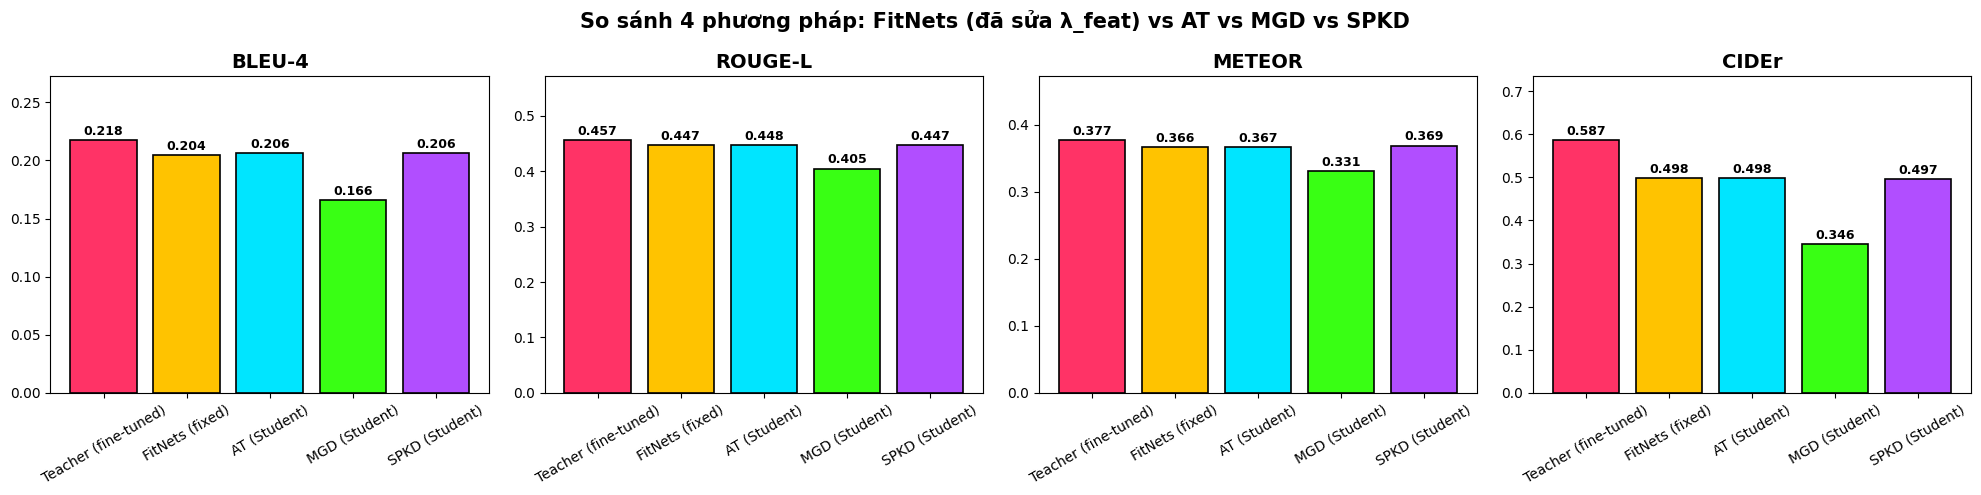

In [22]:
try:
    plt.style.use("seaborn-v0_8-bright")
except (OSError, ValueError):
    pass

COLOR_MAP = dict(zip(accuracy_df.index, run_cfg.bright_colors[: len(accuracy_df.index)]))
metrics_to_plot = ["BLEU-4", "ROUGE-L", "METEOR", "CIDEr"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 5))
for ax, metric in zip(axes, metrics_to_plot):
    values = accuracy_df[metric]
    bars = ax.bar(values.index, values.values, color=[COLOR_MAP[m] for m in values.index], edgecolor="black", linewidth=1.2)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylim(0, max(values.values) * 1.25)
    ax.tick_params(axis="x", rotation=30)
    for bar, v in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(values.values) * 0.02, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
fig.suptitle("So sánh 4 phương pháp: FitNets (đã sửa λ_feat) vs AT vs MGD vs SPKD", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(run_cfg.output_root, "compare_4methods_bar.png"), dpi=150, facecolor="white")
plt.show()


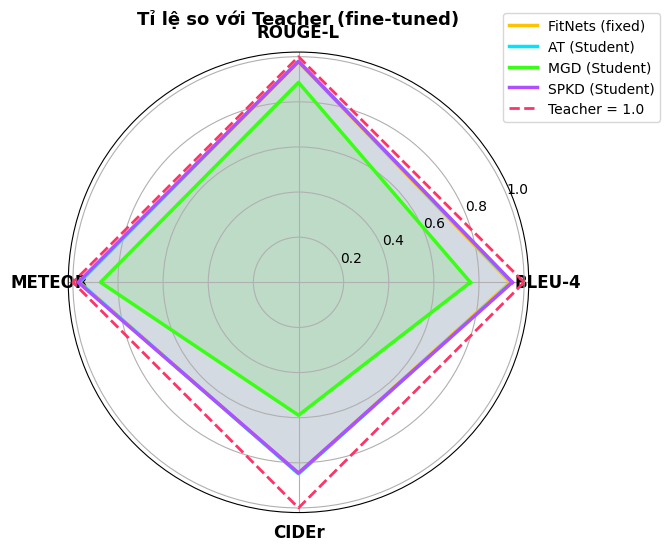

In [23]:
# Radar chart chuan hoa theo Teacher = 1.0
radar_metrics = ["BLEU-4", "ROUGE-L", "METEOR", "CIDEr"]
teacher_vals = accuracy_df.loc["Teacher (fine-tuned)", radar_metrics].values.astype(float)
teacher_vals_safe = np.where(teacher_vals == 0, 1e-8, teacher_vals)
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for model_name in accuracy_df.index:
    if model_name == "Teacher (fine-tuned)":
        continue
    vals = (accuracy_df.loc[model_name, radar_metrics].values.astype(float) / teacher_vals_safe).tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2.5, label=model_name, color=COLOR_MAP[model_name])
    ax.fill(angles, vals, alpha=0.15, color=COLOR_MAP[model_name])
ax.plot(angles, [1.0] * len(angles), linewidth=2, linestyle="--", color=COLOR_MAP["Teacher (fine-tuned)"], label="Teacher = 1.0")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12, fontweight="bold")
ax.set_title("Tỉ lệ so với Teacher (fine-tuned)", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(run_cfg.output_root, "compare_4methods_radar.png"), dpi=150, facecolor="white")
plt.show()


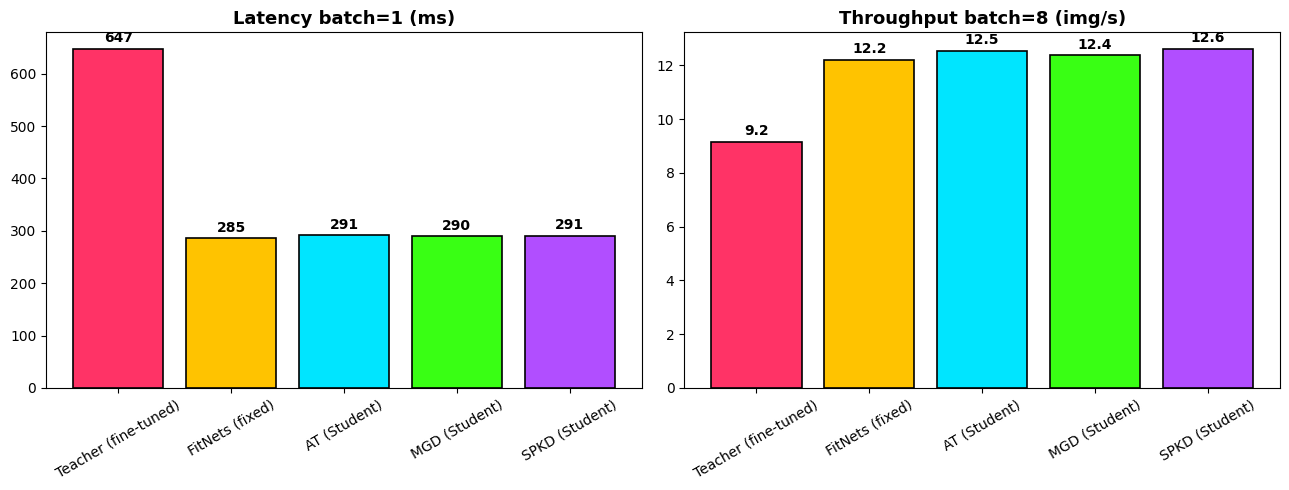

In [24]:
# Latency / throughput
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lat_vals = runtime_df["Latency batch=1 (ms)"]
colors = [COLOR_MAP.get(k, "#888888") for k in lat_vals.index]
bars = axes[0].bar(lat_vals.index, lat_vals.values, color=colors, edgecolor="black", linewidth=1.2)
axes[0].set_title("Latency batch=1 (ms)", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)
for bar, v in zip(bars, lat_vals.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + max(lat_vals.values) * 0.02, f"{v:.0f}", ha="center", fontweight="bold")

thr_col = [c for c in runtime_df.columns if "Throughput" in c][-1]
thr_vals = runtime_df[thr_col]
bars = axes[1].bar(thr_vals.index, thr_vals.values, color=colors, edgecolor="black", linewidth=1.2)
axes[1].set_title(thr_col, fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
for bar, v in zip(bars, thr_vals.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + max(thr_vals.values) * 0.02, f"{v:.1f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(run_cfg.output_root, "compare_4methods_latency.png"), dpi=150, facecolor="white")
plt.show()


## 15. So sánh định tính — caption mẫu của cả 4 phương pháp trên cùng 1 ảnh

Hiển thị lưới ảnh kèm caption sinh ra từ Teacher + 4 Student, viền màu theo đúng bảng màu ở trên,
để nhìn trực quan sự khác biệt về "cách diễn đạt" giữa các phương pháp (không chỉ số liệu).

22:39:25 | INFO    | HTTP Request: HEAD https://huggingface.co/datasets/qa994/blip-kd-results-fitnes-at-fashion200k/resolve/main/kaggle_run_fitnets_at/best_student_at.pth "HTTP/1.1 302 Found"
22:39:25 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:39:25 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
22:39:25 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:39:25 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Salesforce/blip-image-captioning-base/82a37760796d32b1411fe092ab5d4e227313294b/config.json "HTTP/1.1 200 OK"
22:39:25 | INFO    | HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captionin

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

22:39:25 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/commits/main "HTTP/1.1 200 OK"
22:39:26 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key     

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

22:39:29 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

22:39:33 | INFO    | HTTP Request: GET https://huggingface.co/api/models/Salesforce/blip-image-captioning-base/discussions?p=0 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings

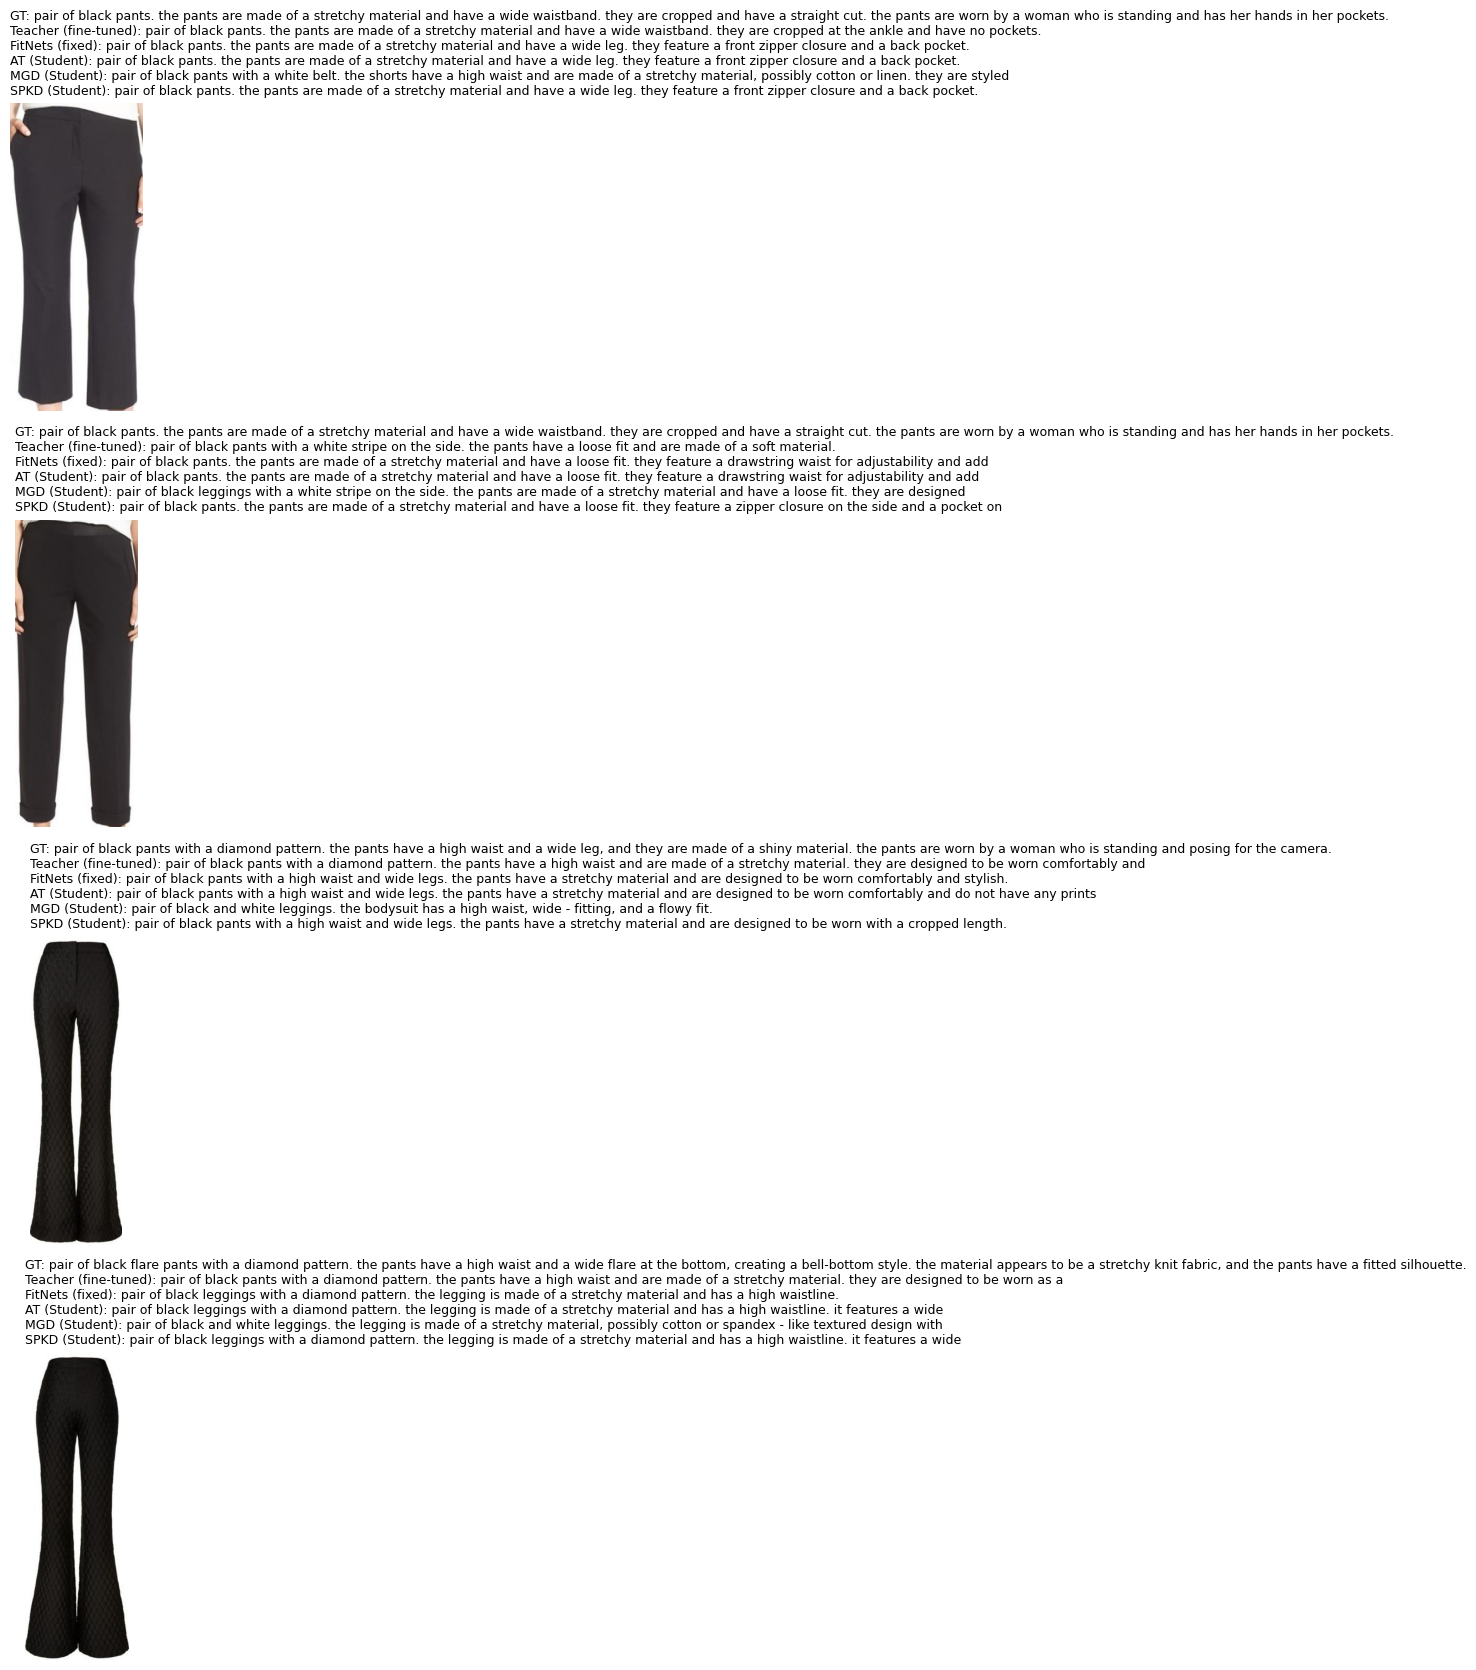

,Ground Truth,Teacher (fine-tuned),FitNets (fixed),AT (Student),MGD (Student),SPKD (Student)
0,pair of black pants. the pants are made of a s...,pair of black pants. the pants are made of a s...,pair of black pants. the pants are made of a s...,pair of black pants. the pants are made of a s...,pair of black pants with a white belt. the sho...,pair of black pants. the pants are made of a s...
1,pair of black pants. the pants are made of a s...,pair of black pants with a white stripe on the...,pair of black pants. the pants are made of a s...,pair of black pants. the pants are made of a s...,pair of black leggings with a white stripe on ...,pair of black pants. the pants are made of a s...
2,pair of black pants with a diamond pattern. th...,pair of black pants with a diamond pattern. th...,pair of black pants with a high waist and wide...,pair of black pants with a high waist and wide...,pair of black and white leggings. the bodysuit...,pair of black pants with a high waist and wide...
3,pair of black flare pants with a diamond patte...,pair of black pants with a diamond pattern. th...,pair of black leggings with a diamond pattern....,pair of black leggings with a diamond pattern....,pair of black and white leggings. the legging ...,pair of black leggings with a diamond pattern....


In [25]:
@torch.no_grad()
def generate_one_caption(model: nn.Module, image: Image.Image, is_teacher: bool) -> str:
    inputs = SHARED_PROCESSOR(images=image, return_tensors="pt").to(DEVICE)
    if is_teacher or next(model.parameters()).dtype == torch.float16:
        inputs["pixel_values"] = inputs["pixel_values"].half()
    gen_ids = model.generate(**inputs, **gen_cfg.as_kwargs())
    return SHARED_PROCESSOR.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()


N_QUALITATIVE_SAMPLES = 4
qualitative_samples = fashion_test[:N_QUALITATIVE_SAMPLES]

qualitative_results: Dict[str, List[str]] = {"Teacher (fine-tuned)": [], "fitnets_fixed": [], "at": [], "mgd": [], "spkd": []}
qualitative_results["Teacher (fine-tuned)"] = [generate_one_caption(teacher_model, Image.open(s["image_path"]).convert("RGB"), True) for s in qualitative_samples]
qualitative_results["fitnets_fixed"] = [generate_one_caption(student_model, Image.open(s["image_path"]).convert("RGB"), False) for s in qualitative_samples]

for method_name, source in OTHER_CHECKPOINTS.items():
    m = download_and_load_student(source, method_name)
    qualitative_results[method_name] = [generate_one_caption(m, Image.open(s["image_path"]).convert("RGB"), False) for s in qualitative_samples]
    free_gpu(m)

fig, axes = plt.subplots(N_QUALITATIVE_SAMPLES, 1, figsize=(9, 4.2 * N_QUALITATIVE_SAMPLES))
if N_QUALITATIVE_SAMPLES == 1:
    axes = [axes]

for row_ax, sample in zip(axes, qualitative_samples):
    idx = qualitative_samples.index(sample)
    img = Image.open(sample["image_path"]).convert("RGB")
    row_ax.imshow(img)
    row_ax.axis("off")
    text_lines = [f"GT: {sample['caption']}"]
    for k in MODEL_ORDER:
        text_lines.append(f"{DISPLAY_NAMES[k]}: {qualitative_results[k][idx]}")
    row_ax.set_title("\n".join(text_lines), fontsize=9, loc="left", color="black")

plt.tight_layout()
plt.savefig(os.path.join(run_cfg.output_root, "qualitative_4methods.png"), dpi=150, facecolor="white")
plt.show()

qual_df = pd.DataFrame({DISPLAY_NAMES[k]: v for k, v in qualitative_results.items()})
qual_df.insert(0, "Ground Truth", [s["caption"] for s in qualitative_samples])
display(qual_df)
qual_df.to_csv(os.path.join(run_cfg.output_root, "qualitative_captions.csv"), index=False)


## 16. Lưu tổng hợp kết quả cuối cùng

In [26]:
final_summary = {
    "accuracy": accuracy_results,
    "runtime": {k: {kk: vv for kk, vv in v.items() if kk != "throughput_by_batch"} for k, v in runtime_results.items()},
    "fitnets_fix_cfg": fitnets_fix_cfg.__dict__,
    "best_val_loss_fitnets_fixed": best_val_loss,
}
with open(os.path.join(run_cfg.output_root, "final_4method_comparison.json"), "w", encoding="utf-8") as f:
    json.dump(final_summary, f, ensure_ascii=False, indent=2, default=str)

logger.info(f"Da luu ket qua cuoi cung -> {run_cfg.output_root}")
logger.info("Hoan tat: FitNets (fixed) da duoc train lai 6 epoch + gop so sanh day du 4 phuong phap.")


22:39:37 | INFO    | Da luu ket qua cuoi cung -> /kaggle/working/fitnets_fix_outputs
22:39:37 | INFO    | Hoan tat: FitNets (fixed) da duoc train lai 6 epoch + gop so sanh day du 4 phuong phap.
